## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 3 

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**UPDATE THIS TO MATCH YOUR POINT TOTAL**</font> possible on this quiz and each part of the quiz can be done independently. **If you get stuck _move on to another part of the quiz to earn some points there!_**

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.

**NOTE: If you use generative AI, you must copy/paste into a cell in this quiz (1) your prompt, (2) the output from chatGPT, and (3) Write your answer in separate cells. Failure to include this level of detail will result in a deduction of points.**

<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---

# 1. Analyzing TikTok data from internet (50 points)

For this quiz we'll use SciPy's `curve_fit`  and data from  [**Google Trends**](https://trends.google.com/trends/)  to develop a model to forecast the adoption of TikTok. The specific goals of the quiz are for you to:
* load the provided data using Pandas or Numpy
* Fit the model described below to the data (i.e., finding the right paramters) using  SciPy's `curve_fit`
* visualize the data and the best fit model using Matplotlib or Seaborn
* answer conceptual questions based on the model results

In this data set, you will find
* **Date**: month/day/year of the measurement. First week: 07/29/18, last week: 11/01/20
* **Week**: number of weeks since the last measurement. There is a total of 119 weeks of data.
* **SI**: "These numbers represent search interest (SI) relative to the highest value for the given region and time. A value of 100 is the peak popularity for the term. A value of 50 means that the term is half as popular. A score of 0 means there was not enough data for this term."
* **CSI**: Commulative Search Interest; this is the total search interest up to the current week
* **NCSI**: Normalized Cummulative Search Interest; this the same as CSI but normalized so that the maxium (i.e., last) value is 1.

#### &#9989;&nbsp; **Question 1.1 (5 points)** 
Load the `TikTok.csv` file provided on D2L **using Pandas** and display the first 10 rows.

In [2]:
# Let's make sure pandas is imported
import pandas as pd

# Put your code here


In [1]:
### ANSWER
import pandas as pd

pl = pd.read_csv("TikTok.csv")
pl.head(10)

,Date,Week,SI,CSI,NCSI
0,07/29/18,1,1,1,0.000345
1,08/05/18,2,1,2,0.000690
2,08/12/18,3,1,3,0.001035
3,08/19/18,4,1,4,0.001380
4,08/26/18,5,1,5,0.001725
5,09/02/18,6,2,7,0.002415
6,09/09/18,7,2,9,0.003106
7,09/16/18,8,2,11,0.003796
8,09/23/18,9,2,13,0.004486
9,09/30/18,10,3,16,0.005521


#### &#9989;&nbsp; **Question 1.2 (15 points)** 
You want to narrow down your visualization to just certain time periods. Choose data that corresponds to CSI number between 2 and 20.

Create a mask that filters the data to show only the rows that match the CSI range you chose.

**Display that dataframe once you've created it**, to confirm that you did it correctly.

**Note**: if you didn't get the dataset loaded correctly, try your best to write the code that **should** appropriately mask the data for partial credit.

In [18]:
# Put your code here


In [2]:
### ANSWER


df = pl[(pl["CSI"] >= 2) & (pl["CSI"] <=20) ]
df.head()
df.tail()

# Rubric
# 5 points for any masking attempt
# 5 points for a correct mask
# 5 points for display

,Date,Week,SI,CSI,NCSI
6,09/09/18,7,2,9,0.003106
7,09/16/18,8,2,11,0.003796
8,09/23/18,9,2,13,0.004486
9,09/30/18,10,3,16,0.005521
10,10/07/18,11,3,19,0.006556


#### &#9989;&nbsp; **Question 1.3 (10 points)** 

Finally, you are curious about the overall information of the corresponding 'NCSI' column that you selected above. **Write some code to calculate and display the mean** for the NCSI column of your masked dataframe.

**Note #1**: there's more than one way you could do this.

**Note #2**: if you didn't get the dataset loaded correctly, try your best to write the code that **should** calculate and display the mean for partial credit.

In [21]:
# Put your code here


From the output of your code, what is the mean for the total weight lifted?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

In [3]:
### ANSWER
# Using "describe"
df['NCSI'].describe()
# Technically they could call describe on the full dataframe, but this is more explicit
# Either option is fine



count    10.000000
mean      0.003071
std       0.001989
min       0.000690
25%       0.001467
50%       0.002761
75%       0.004313
max       0.006556
Name: NCSI, dtype: float64

In [13]:
### ANSWER
# Using "mean" from numpy
import numpy as np
print(np.mean(df['NCSI']))


0.0030710835


### ANSWER

The mean is (test this for yourself)

#### &#9989;&nbsp; **Question 1.4 Documenting Your Solution Pathway (20 points)**

**Describe in detail** how you solved the problem including any external resources you consulted (e.g. generative AI **prompts and outputs**, past assignments, Code Portfolio, Stack Overflow, Google, etc.) and how they informed your approach. You must also describe how you know your solution works (e.g. and calculations you made, tests you ran, etc.)

If you did not use external resources, describe your thought process for solving the problem by answering the following questions:
1. How did you know where to start?
2. What prior knowledge did you recall to solve the problem?
3. How do you know that your solution works?

<font size=+3>&#9998;</font> *Put your answer here.*

---
# 2. Fitting a model to data with `curve_fit` and visualizing the results (40 points)

#### &#9989;&nbsp; **Question 2.1 (10 points):**: Now that you've loaded the data, recall that the Bass diffusion model for adopters is given by:

$$A(t) = M\frac{1 - e^{-(p+q)t}}{1 + \frac{q}{p}e^{-(p+q)t}}$$

**Write a function called `bass` in the cell below that returns the value of $A$ at a given time, $t$**. The function should take as input $t$ (numpy array), $p$ (float), $q$ (float), and $M$(float), and return the values $A(t)$ (numpy array). Make sure to use the NumPy `np.exp()` function to ensure that your function will work for an *array* of time values!

In [4]:
# Define the bass function here

### ANSWER ###
def bass(t, p, q, M):   
    A = M * (1 - np.exp(-t * (p + q))) / (1 + (q / p) * np.exp(-t * (p + q)))
    return  A

---

#### &#9989;&nbsp; **Question 2.2 (10 points):** 

Now that you have the fuction `bass`,  **use Scipy's `curve_fit` function to estimate the parameters $p,q,M$ for the Bass model on the TikTok Google Trends data**. The documentation for `curve_fit` can be found [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html).

Recall that "Week" is the time variable, and  "NCSI" is your adoption "$A$" value.

Once you have the estimated parameter values, **print them**.

(Note: You may get a "RuntimeWarning: overflow" message, which you can safely igonre and move on) 

In [5]:
# Call the curve_fit function here
### ANSWER ###
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np


### ANSWER ###
t = pl['Week']
A = pl["NCSI"]

popt, pcov = curve_fit(bass, t, A )


# Print the parameter p, q, M

innovation, imitation,  max_potential = popt
print("Innovation: %f, Imitation: %f, Market Cap: %f" %(innovation,imitation,max_potential))

Innovation: 0.000271, Imitation: 0.040068, Market Cap: 2.307706


C:\Program Files\Anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### &#9989;&nbsp; **Question 2.3 (10 points)** 

Now that you've used `curve_fit` to estimate the parameters of the model, use them along with your `bass` function to compute the expected adoption values for TikTok over time.  **Plot the original data along with the expected values from the model in the cell below.** Label your axes and include a legend to make it clear what part of the plot represents the data and what part represents the model.

In [10]:
# Make sure we import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Put your code here

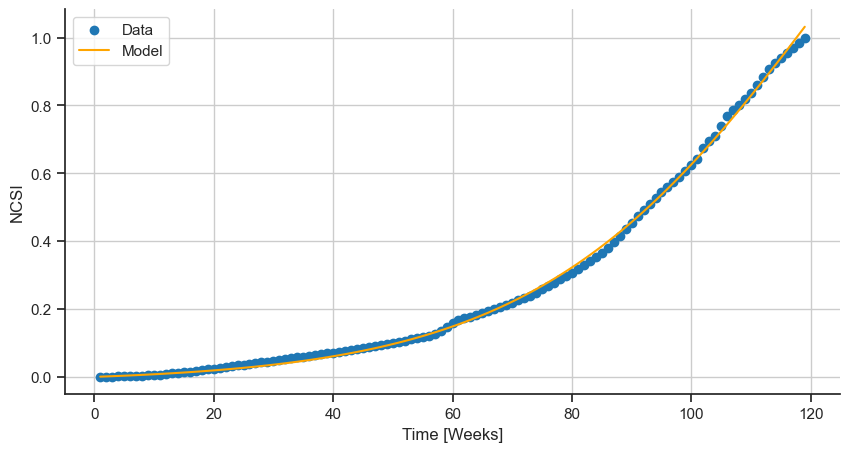

In [11]:
### ANSWER ###
A_est = bass(t, innovation, imitation, max_potential)


# Put your plot code here

### ANSWER ###
plt.figure(figsize=(10,5))
plt.scatter(t, A,label="Data")
plt.plot(t, A_est, color="orange",label="Model")
plt.xlabel("Time [Weeks]")
plt.ylabel("NCSI")
plt.legend()
plt.grid()

sns.set_style("ticks")
sns.set_context("notebook")
sns.despine()

# Rubric
# 10 pts for data and best fit
# 10 pts for labels, legend, etc.

#### &#9989;&nbsp; **Question 2.3 Documenting Your Solution Pathway (20 points)**

**Describe in detail** how you solved the problem including any external resources you consulted (e.g. generative AI **prompts and outputs**, past assignments, Code Portfolio, Stack Overflow, Google, etc.) and how they informed your approach. You must also describe how you know your solution works (e.g. and calculations you made, tests you ran, etc.)

If you did not use external resources, describe your thought process for solving the problem by answering the following questions:
1. How did you know where to start?
2. What prior knowledge did you recall to solve the problem?
3. How do you know that your solution works?

<font size=+3>&#9998;</font> *Put your answer here.*

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #3, and upload it there.